In [34]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Максимальное количество строк для отображения
pd.set_option('display.max_rows', None)
# Максимальное количество столбцов для отображения
pd.set_option('display.max_columns', None)
# Ширина каждого столбца (в символах)
pd.set_option('display.width', 1000)
# Максимальное количество символов для отображения в ячейке
pd.set_option('display.max_colwidth', None)


<h3>Загрузка данных</h3>
<p>Загрузите файл dip_hw_x_taxi.csv в pandas dataframe</p>
<p>Рассчитайте основные описательные статистики (среднее, минимум, 25-50-75-персентили, максимум)	</p>
<p>Вычислите количество значений по классам такси	</p>
<p>Визуализируйте распределение дистанций поездок	</p>
<p>Визуализируйте распределения дистанций поездок, по каждому классу такси в отдельности, а также определите типы распределений для эконом-класса и комфорт-класса	</p>

In [9]:
df = pd.read_csv('dip_hw_x_taxi.csv')
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_gk           2000 non-null   int64  
 1   weekday_key        2000 non-null   int64  
 2   hour_key           2000 non-null   int64  
 3   distance_km        2000 non-null   float64
 4   offer_class_group  2000 non-null   object 
 5   driver_response    2000 non-null   int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 93.9+ KB


order_gk             0
weekday_key          0
hour_key             0
distance_km          0
offer_class_group    0
driver_response      0
dtype: int64

In [20]:
# проверка дублей
duplicates = df[df.duplicated(subset=['order_gk'], keep=False)]
if len(duplicates) > 0:
    print(f"\n Количество дублей: {len(duplicates)}")
    print(f"\n", duplicates.sort_values('order_gk').to_string())
else:
    print("Дубликатов не найдено")


 Количество дублей: 29

       order_gk  weekday_key  hour_key  distance_km offer_class_group  driver_response
316     137561            5        14       24.105          Delivery                1
317     137561            5        13       27.106          Delivery                1
463     204860            3         0       25.803          Delivery                1
464     204860            2        23       14.619          Delivery                0
519     234733            5        20       16.633          Delivery                1
520     234733            5         6       15.141          Delivery                0
581     266312            6        14       73.527           Economy                0
582     266312            3        14       23.430           Economy                0
763     354450            3        21       10.290          Delivery                0
764     354450            1        16       17.271          Delivery                1
765     354497            1 

<p>2000 на 6 размерность датасета, пустых значений нет.</p>
<p>Но есть одинаковые ордера, хоть и в разные дни и часы, наверное это допустимо в данном случае (хотя по идее должны быть уникальны id) </p>

In [13]:
# Все числовых столбцов
print("Основные описательные статистики для всех числовых столбцов:")
desc_stats = df.describe()
print(desc_stats)

Основные описательные статистики для всех числовых столбцов:
            order_gk  weekday_key     hour_key  distance_km  driver_response
count    2000.000000  2000.000000  2000.000000  2000.000000      2000.000000
mean   462807.384000     4.044000    11.608500    26.275848         0.587000
std    270556.211847     2.007256     6.918465    18.876336         0.492496
min       412.000000     1.000000     0.000000     0.024000         0.000000
25%    227126.500000     2.000000     6.000000    12.177000         0.000000
50%    458637.000000     4.000000    12.000000    22.828500         1.000000
75%    709420.250000     6.000000    18.000000    36.434250         1.000000
max    919196.000000     7.000000    23.000000   138.950000         1.000000


In [15]:
# Отдельно для distance_km, так как это наш основной показатель
print("Детальная статистика для distance_km (дистанция в км):")
distance_stats = df['distance_km'].describe()
print(distance_stats)

Детальная статистика для distance_km (дистанция в км):
count    2000.000000
mean       26.275848
std        18.876336
min         0.024000
25%        12.177000
50%        22.828500
75%        36.434250
max       138.950000
Name: distance_km, dtype: float64


<p>Средняя дистанция: 26.28 км

Медиана: 22.83 км (правостороннее распределение)

25% поездок короче 12.18 км

75% поездок короче 36.43 км

Разброс от 0.02 км до 138.95 км</p>

In [25]:
# Количество значений по классам такси
class_counts = df['offer_class_group'].value_counts()  

# Классы поездок в процентах
class_percentages = (df['offer_class_group'].value_counts(normalize=True) * 100).round(2)

print(f"\n", class_counts)
print(f"\n",class_percentages)



 offer_class_group
Premium     500
Delivery    500
Comfort     500
Economy     500
Name: count, dtype: int64

 offer_class_group
Premium     25.0
Delivery    25.0
Comfort     25.0
Economy     25.0
Name: proportion, dtype: float64


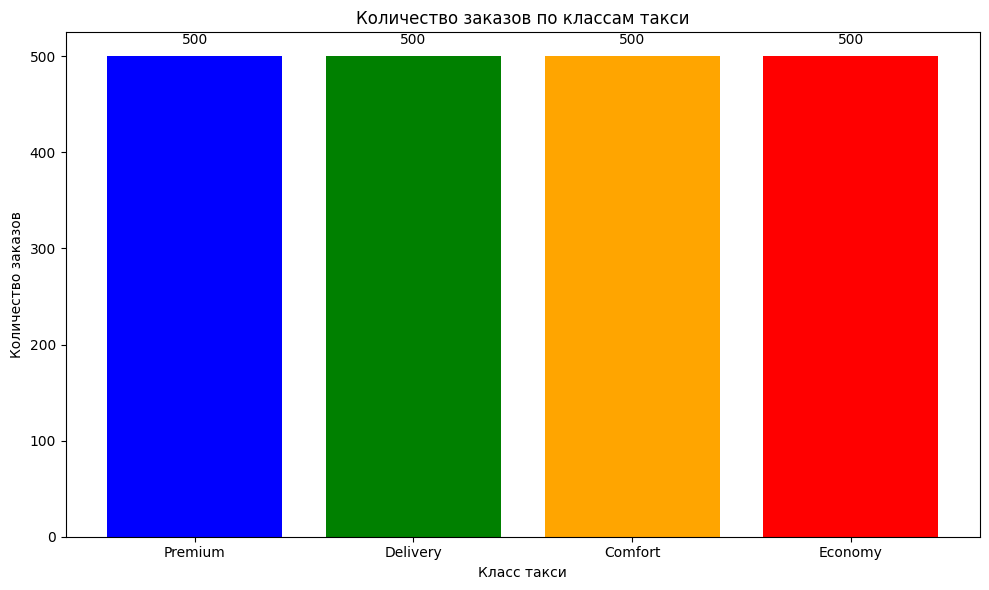

In [26]:
plt.figure(figsize=(10, 6))
bars = plt.bar(class_counts.index, class_counts.values, color=['blue', 'green', 'orange', 'red'])
plt.title('Количество заказов по классам такси')
plt.xlabel('Класс такси')
plt.ylabel('Количество заказов')

# Добавляем подписи на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

<p>Странно что количество одинаковое, наверное так задумано, получается по 500 поездок кажого типа</p>

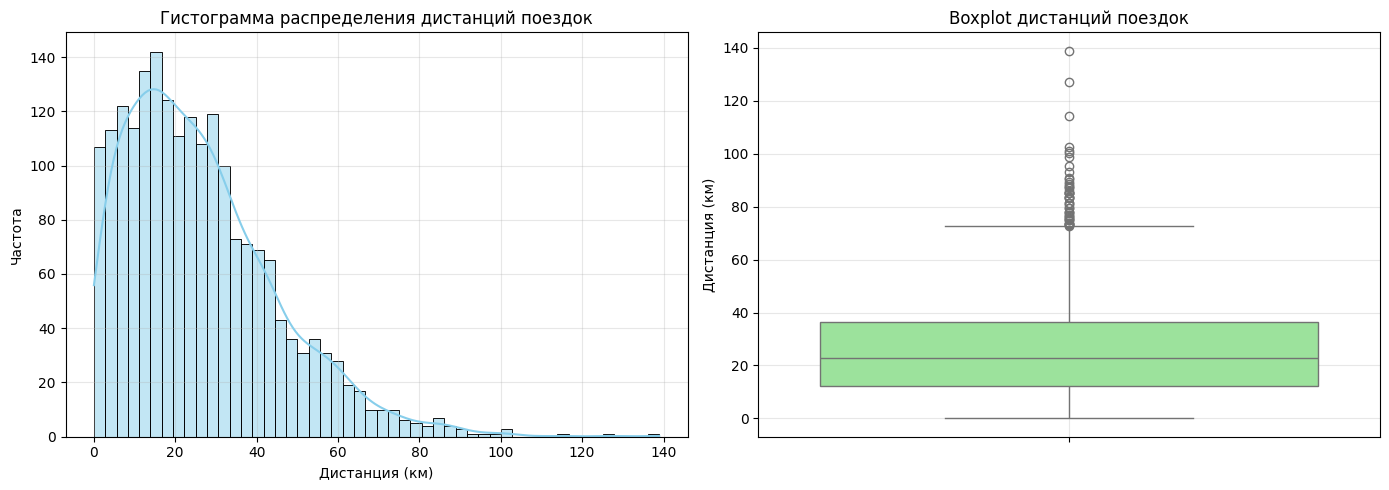


 Характеристики распределения дистанций:
   Среднее: 26.28 км
   Медиана: 22.83 км
   Асимметрия (skewness): 1.12
   Эксцесс (kurtosis): 1.79

Анализ выбросов (правило 1.5*IQR):
   Q1 (25-й персентиль): 12.18 км
   Q3 (75-й персентиль): 36.43 км
   IQR: 24.26 км
   Нижняя граница: -24.21 км
   Верхняя граница: 72.82 км
   Количество выбросов: 46 (2.3% данных)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гистограмма с KDE (Kernel Density Estimation)
sns.histplot(data=df, x='distance_km', bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Гистограмма распределения дистанций поездок')
axes[0].set_xlabel('Дистанция (км)')
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

# 2. Boxplot для выявления выбросов
sns.boxplot(data=df, y='distance_km', ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot дистанций поездок')
axes[1].set_ylabel('Дистанция (км)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная информация о распределении
print("\n Характеристики распределения дистанций:")
print(f"   Среднее: {df['distance_km'].mean():.2f} км")
print(f"   Медиана: {df['distance_km'].median():.2f} км")
print(f"   Асимметрия (skewness): {df['distance_km'].skew():.2f}")
print(f"   Эксцесс (kurtosis): {df['distance_km'].kurtosis():.2f}")

# Определим процент выбросов (по правилу 1.5*IQR)
Q1 = df['distance_km'].quantile(0.25)
Q3 = df['distance_km'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['distance_km'] < lower_bound) | (df['distance_km'] > upper_bound)]
outlier_percentage = (len(outliers) / len(df)) * 100

print(f"\nАнализ выбросов (правило 1.5*IQR):")
print(f"   Q1 (25-й персентиль): {Q1:.2f} км")
print(f"   Q3 (75-й персентиль): {Q3:.2f} км")
print(f"   IQR: {IQR:.2f} км")
print(f"   Нижняя граница: {lower_bound:.2f} км")
print(f"   Верхняя граница: {upper_bound:.2f} км")
print(f"   Количество выбросов: {len(outliers)} ({outlier_percentage:.1f}% данных)")

<p>Распределение является правосторонним (положительная асимметрия = 1.12)</p>
<p>Большинство поездок короткие (медиана 22.8 км)

Среднее (26.3 км) больше медианы, что подтверждает правосторонний сдвиг</p>

Распределения дистанций по каждому классу такси


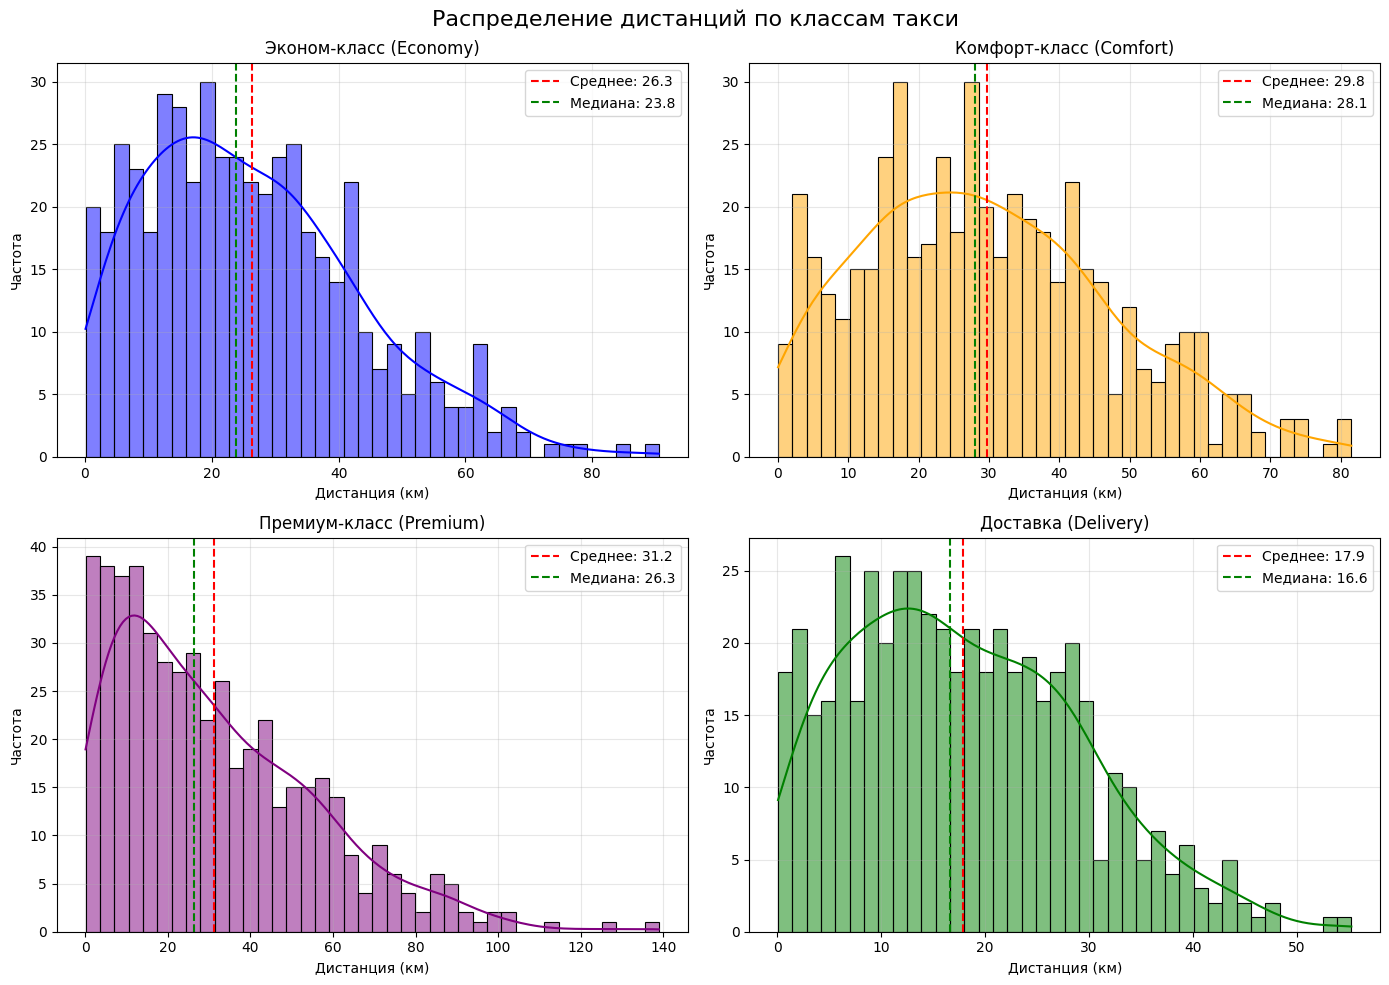


 Анализ типов распределений для Эконом и Комфорт классов:

 ДЕТАЛЬНЫЙ АНАЛИЗ:

--------------------------------------------------
Анализ распределения для ЭКОНОМ-КЛАСС (Economy):
   Среднее: 26.28 км
   Медиана: 23.80 км
   Асимметрия (skewness): 0.70
   Эксцесс (kurtosis): 0.18
   Тип распределения: правостороннее (положительная асимметрия), остроконечное (лептокуртическое)
   Среднее > Медианы → распределение сдвинуто вправо

--------------------------------------------------
Анализ распределения для КОМФОРТ-КЛАСС (Comfort):
   Среднее: 29.76 км
   Медиана: 28.08 км
   Асимметрия (skewness): 0.48
   Эксцесс (kurtosis): -0.28
   Тип распределения: примерно симметричное, плосковершинное (платикуртическое)
   Среднее > Медианы → распределение сдвинуто вправо

 Сравнительная визуализация Economy vs Comfort:


C:\Users\alexg\AppData\Local\Temp\ipykernel_16960\3531920883.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=class_data, x='Class', y='distance_km',


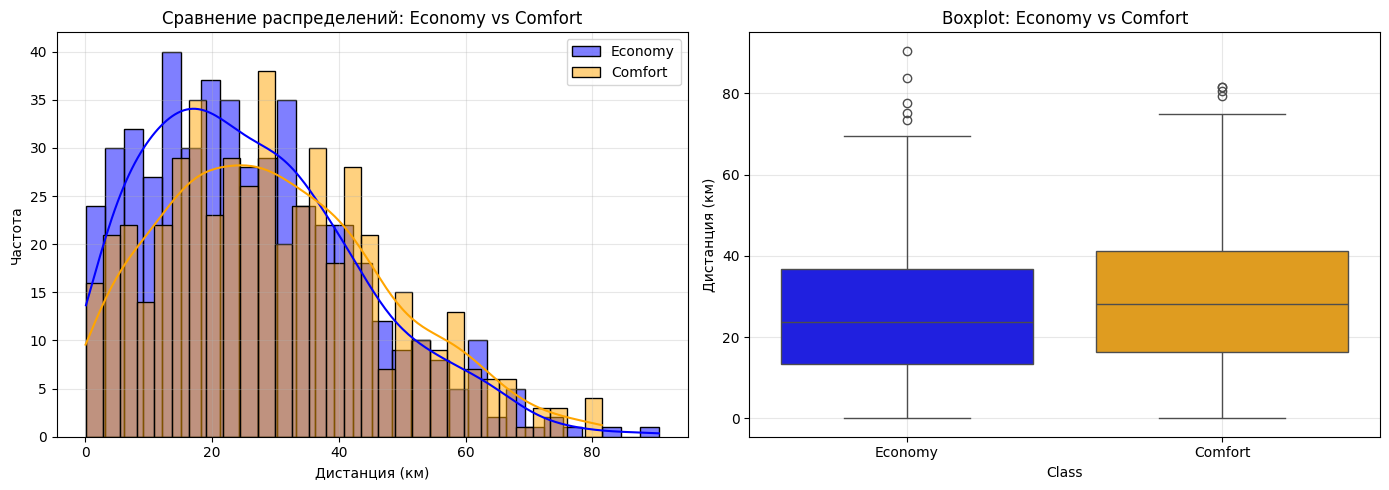

In [32]:
print("Распределения дистанций по каждому классу такси")

# Отдельные наборы по классам
economy_df = df[df['offer_class_group'] == 'Economy']
comfort_df = df[df['offer_class_group'] == 'Comfort']
premium_df = df[df['offer_class_group'] == 'Premium']
delivery_df = df[df['offer_class_group'] == 'Delivery']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределение дистанций по классам такси', fontsize=16)

# Функция для построения гистограммы с KDE
def plot_distribution(ax, data, title, color):
    sns.histplot(data=data, x='distance_km', bins=40, kde=True, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Дистанция (км)')
    ax.set_ylabel('Частота')
    ax.grid(True, alpha=0.3)
    # Добавляем вертикальные линии для среднего и медианы
    ax.axvline(data['distance_km'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {data["distance_km"].mean():.1f}')
    ax.axvline(data['distance_km'].median(), color='green', linestyle='--', linewidth=1.5, label=f'Медиана: {data["distance_km"].median():.1f}')
    ax.legend()

# Эконом-класс
plot_distribution(axes[0, 0], economy_df, 'Эконом-класс (Economy)', 'blue')

# Комфорт-класс
plot_distribution(axes[0, 1], comfort_df, 'Комфорт-класс (Comfort)', 'orange')

# Премиум-класс
plot_distribution(axes[1, 0], premium_df, 'Премиум-класс (Premium)', 'purple')

# Доставка
plot_distribution(axes[1, 1], delivery_df, 'Доставка (Delivery)', 'green')

plt.tight_layout()
plt.show()

# Типы распределений для Economy и Comfort
print("\n Анализ типов распределений для Эконом и Комфорт классов:")

def analyze_distribution(data, class_name):
    print(f"\n{'-'*50}")
    print(f"Анализ распределения для {class_name}:")
    print(f"   Среднее: {data['distance_km'].mean():.2f} км")
    print(f"   Медиана: {data['distance_km'].median():.2f} км")
    print(f"   Асимметрия (skewness): {data['distance_km'].skew():.2f}")
    print(f"   Эксцесс (kurtosis): {data['distance_km'].kurtosis():.2f}")
    
    # Тип распределения по асимметрии
    skewness = data['distance_km'].skew()
    if abs(skewness) < 0.5:
        skew_type = "примерно симметричное"
    elif skewness > 0:
        skew_type = "правостороннее (положительная асимметрия)"
    else:
        skew_type = "левостороннее (отрицательная асимметрия)"
    
    # Тип распределения по эксцессу
    kurt = data['distance_km'].kurtosis()
    if kurt > 0:
        kurt_type = "остроконечное (лептокуртическое)"
    elif kurt < 0:
        kurt_type = "плосковершинное (платикуртическое)"
    else:
        kurt_type = "нормальное (мезокуртическое)"
    
    print(f"   Тип распределения: {skew_type}, {kurt_type}")
    
    # Сравнение среднего и медианы
    if data['distance_km'].mean() > data['distance_km'].median():
        print(f"   Среднее > Медианы → распределение сдвинуто вправо")
    elif data['distance_km'].mean() < data['distance_km'].median():
        print(f"   Среднее < Медианы → распределение сдвинуто влево")
    else:
        print(f"   Среднее ≈ Медиане → симметричное распределение")
    
    return skewness, kurt

# Анализ Economy и Comfort
print("\n ДЕТАЛЬНЫЙ АНАЛИЗ:")
skew_economy, kurt_economy = analyze_distribution(economy_df, "ЭКОНОМ-КЛАСС (Economy)")
skew_comfort, kurt_comfort = analyze_distribution(comfort_df, "КОМФОРТ-КЛАСС (Comfort)")

# Визуальное представления -  Economy vs Comfort
print("\n Сравнительная визуализация Economy vs Comfort:")

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 5))

# Гистограммы на одном графике
sns.histplot(data=economy_df, x='distance_km', bins=30, kde=True, 
             color='blue', alpha=0.5, label='Economy', ax=ax2[0])
sns.histplot(data=comfort_df, x='distance_km', bins=30, kde=True, 
             color='orange', alpha=0.5, label='Comfort', ax=ax2[0])
ax2[0].set_title('Сравнение распределений: Economy vs Comfort')
ax2[0].set_xlabel('Дистанция (км)')
ax2[0].set_ylabel('Частота')
ax2[0].legend()
ax2[0].grid(True, alpha=0.3)

# Boxplot для сравнения
class_data = pd.concat([
    economy_df[['distance_km']].assign(Class='Economy'),
    comfort_df[['distance_km']].assign(Class='Comfort')
])
sns.boxplot(data=class_data, x='Class', y='distance_km', 
            palette=['blue', 'orange'], ax=ax2[1])
ax2[1].set_title('Boxplot: Economy vs Comfort')
ax2[1].set_ylabel('Дистанция (км)')
ax2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<p>Поездки комфортом предпочитают для больших дистанций, короткие судя по всему предпочтение отдается эконому<p>

<p>Сформируйте выборки по эконом и комфорт-классам. Визуализируйте пересечение интервалов дистанций этих классов</p>

 Пункт 6: Пересечение интервалов дистанций Economy и Comfort классов
 Выборки уже сформированы:
   Economy: 500 записей
   Comfort: 500 записей

 Визуализация пересечения интервалов дистанций:


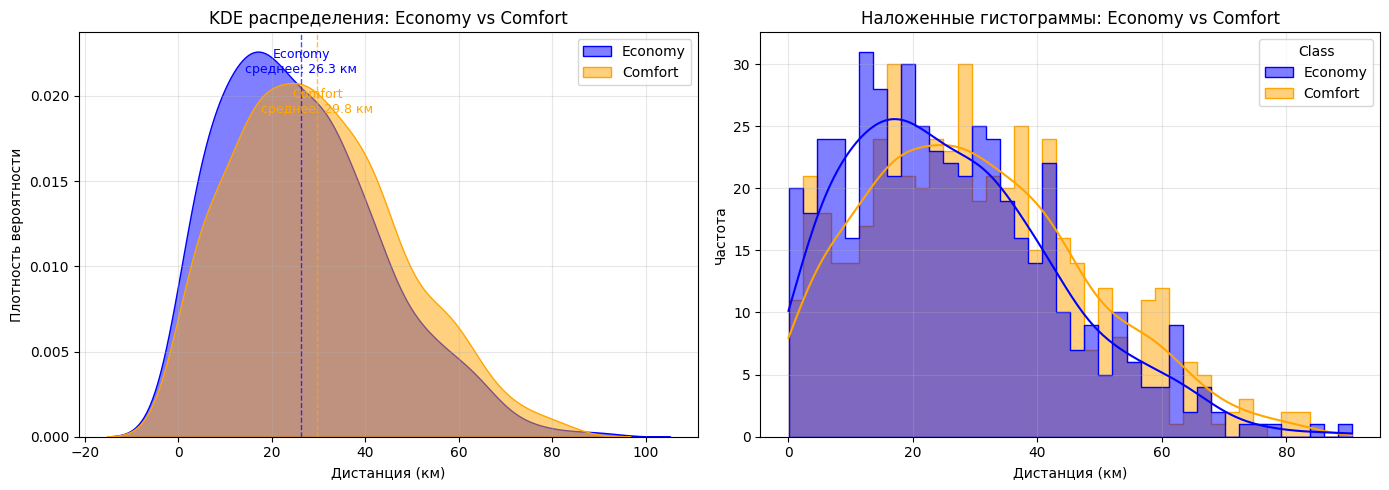


 Пересечения интервалов:
Сравнение квантилей распределений:
Процентиль  Economy (км)  Comfort (км)  Разница (км)
     10.0%          5.81          6.85          1.05
     25.0%         13.37         16.35          2.97
     50.0%         23.80         28.08          4.28
     75.0%         36.85         41.30          4.46
     90.0%         50.03         55.40          5.38

 Диапазоны распределений:

 Основные метрики распределений:
  Class   Min      Q1  Median       Q3    Max      IQR
Economy 0.090 13.3725 23.7980 36.84525 90.517 23.47275
Comfort 0.024 16.3455 28.0785 41.30100 81.507 24.95550

 Область пересечений:
   Общий диапазон данных: от 0.09 км до 81.51 км
   Длина общего диапазона: 81.42 км

 Точки пересечения распределений (где один класс начинает преобладать над другим):
   Точка 1: 23.66 км
     До 23.7 км преобладает: Economy
     После 23.7 км преобладает: Economy

 Финальная визуализация с выделением области пересечения:


C:\Users\alexg\AppData\Local\Temp\ipykernel_16960\1614847152.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_intersection = np.trapz(y_min, x)
C:\Users\alexg\AppData\Local\Temp\ipykernel_16960\1614847152.py:168: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_economy = np.trapz(y_economy, x)
C:\Users\alexg\AppData\Local\Temp\ipykernel_16960\1614847152.py:169: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_comfort = np.trapz(y_comfort, x)


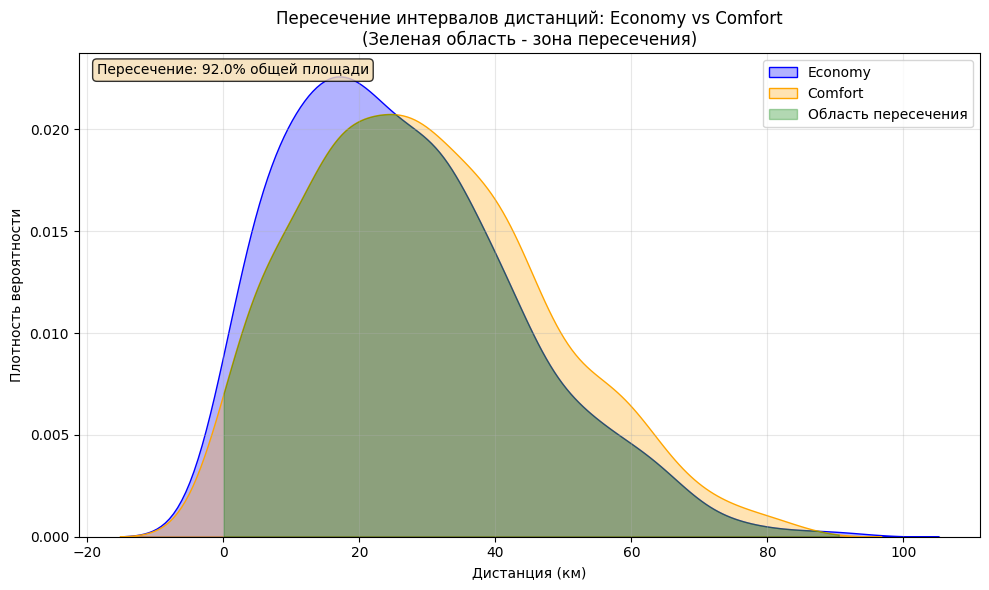


 Показатель пересечения:
   Площадь пересечения распределений: 92.0% от меньшего распределения


In [35]:
print(" Пункт 6: Пересечение интервалов дистанций Economy и Comfort классов")

# 1. Формируем выборки (уже сделали в Пункте 5, но для ясности)
print(" Выборки уже сформированы:")
print(f"   Economy: {len(economy_df)} записей")
print(f"   Comfort: {len(comfort_df)} записей")

# 2. Создаем отдельный DataFrame для удобства визуализации
df_economy_comfort = pd.concat([
    economy_df[['distance_km']].assign(Class='Economy'),
    comfort_df[['distance_km']].assign(Class='Comfort')
])

# 3. Визуализация пересечения интервалов с использованием KDE (Kernel Density Estimation)
print("\n Визуализация пересечения интервалов дистанций:")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: KDE plot для обоих классов на одном графике
sns.kdeplot(data=economy_df, x='distance_km', label='Economy', 
            fill=True, alpha=0.5, color='blue', ax=axes[0])
sns.kdeplot(data=comfort_df, x='distance_km', label='Comfort', 
            fill=True, alpha=0.5, color='orange', ax=axes[0])
axes[0].set_title('KDE распределения: Economy vs Comfort')
axes[0].set_xlabel('Дистанция (км)')
axes[0].set_ylabel('Плотность вероятности')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Добавляем вертикальные линии для средних значений
mean_economy = economy_df['distance_km'].mean()
mean_comfort = comfort_df['distance_km'].mean()
axes[0].axvline(mean_economy, color='blue', linestyle='--', linewidth=1, alpha=0.7)
axes[0].axvline(mean_comfort, color='orange', linestyle='--', linewidth=1, alpha=0.7)
axes[0].text(mean_economy, axes[0].get_ylim()[1]*0.9, f'Economy\nсреднее: {mean_economy:.1f} км', 
             color='blue', ha='center', fontsize=9)
axes[0].text(mean_comfort, axes[0].get_ylim()[1]*0.8, f'Comfort\nсреднее: {mean_comfort:.1f} км', 
             color='orange', ha='center', fontsize=9)

# График 2: Overlapping histogram (гистограммы с наложением)
sns.histplot(data=df_economy_comfort, x='distance_km', hue='Class', 
             bins=40, kde=True, alpha=0.5, palette=['blue', 'orange'], 
             element='step', ax=axes[1])
axes[1].set_title('Наложенные гистограммы: Economy vs Comfort')
axes[1].set_xlabel('Дистанция (км)')
axes[1].set_ylabel('Частота')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Анализ пересечения интервалов
print("\n Пересечения интервалов:")

# Вычисляем основные квантили для обоих классов
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
economy_quantiles = economy_df['distance_km'].quantile(quantiles)
comfort_quantiles = comfort_df['distance_km'].quantile(quantiles)

quantile_df = pd.DataFrame({
    'Процентиль': [f'{q*100}%' for q in quantiles],
    'Economy (км)': economy_quantiles.values.round(2),
    'Comfort (км)': comfort_quantiles.values.round(2),
    'Разница (км)': (comfort_quantiles.values - economy_quantiles.values).round(2)
})

print("Сравнение квантилей распределений:")
print(quantile_df.to_string(index=False))

# 5. Визуализация пересечения в виде диапазонов
print("\n Диапазоны распределений:")

# Создаем DataFrame для визуализации диапазонов
ranges_data = pd.DataFrame({
    'Class': ['Economy', 'Comfort'],
    'Min': [economy_df['distance_km'].min(), comfort_df['distance_km'].min()],
    'Q1': [economy_df['distance_km'].quantile(0.25), comfort_df['distance_km'].quantile(0.25)],
    'Median': [economy_df['distance_km'].median(), comfort_df['distance_km'].median()],
    'Q3': [economy_df['distance_km'].quantile(0.75), comfort_df['distance_km'].quantile(0.75)],
    'Max': [economy_df['distance_km'].max(), comfort_df['distance_km'].max()],
    'IQR': [economy_df['distance_km'].quantile(0.75) - economy_df['distance_km'].quantile(0.25),
            comfort_df['distance_km'].quantile(0.75) - comfort_df['distance_km'].quantile(0.25)]
})

print("\n Основные метрики распределений:")
print(ranges_data.to_string(index=False))

# 6. Определяем область пересечения
print("\n Область пересечений:")

# Вычисляем общий диапазон, где есть данные обоих классов
common_min = max(economy_df['distance_km'].min(), comfort_df['distance_km'].min())
common_max = min(economy_df['distance_km'].max(), comfort_df['distance_km'].max())

print(f"   Общий диапазон данных: от {common_min:.2f} км до {common_max:.2f} км")
print(f"   Длина общего диапазона: {common_max - common_min:.2f} км")

# Проверяем, есть ли статистически значимые различия в распределениях
from scipy import stats

# KDE для вычисления плотности в разных точках
kde_economy = stats.gaussian_kde(economy_df['distance_km'])
kde_comfort = stats.gaussian_kde(comfort_df['distance_km'])

# Выбираем точки для сравнения
test_points = np.linspace(common_min, common_max, 20)
density_diff = kde_economy(test_points) - kde_comfort(test_points)

# Находим область, где распределения пересекаются (меняют относительное преобладание)
crossing_points = []
for i in range(len(test_points)-1):
    if density_diff[i] * density_diff[i+1] < 0:  # Знак меняется
        crossing_points.append((test_points[i] + test_points[i+1]) / 2)

print(f"\n Точки пересечения распределений (где один класс начинает преобладать над другим):")
if crossing_points:
    for i, point in enumerate(crossing_points, 1):
        print(f"   Точка {i}: {point:.2f} км")
        
        # Определяем, какой класс преобладает до и после точки
        test_before = point - 1
        test_after = point + 1
        
        if test_before >= common_min:
            dens_before_e = kde_economy(test_before)
            dens_before_c = kde_comfort(test_before)
            dominant_before = "Economy" if dens_before_e > dens_before_c else "Comfort"
            
        if test_after <= common_max:
            dens_after_e = kde_economy(test_after)
            dens_after_c = kde_comfort(test_after)
            dominant_after = "Economy" if dens_after_e > dens_after_c else "Comfort"
            
            print(f"     До {point:.1f} км преобладает: {dominant_before}")
            print(f"     После {point:.1f} км преобладает: {dominant_after}")
else:
    print("   Нет явных точек пересечения - одно распределение всегда преобладает над другим")

# Визуализация области пересечения с заливкой
print("\n Финальная визуализация с выделением области пересечения:")

fig2, ax2 = plt.subplots(figsize=(10, 6))

# KDE графики
sns.kdeplot(data=economy_df, x='distance_km', label='Economy', 
            fill=True, alpha=0.3, color='blue', ax=ax2)
sns.kdeplot(data=comfort_df, x='distance_km', label='Comfort', 
            fill=True, alpha=0.3, color='orange', ax=ax2)

# Заливаем область пересечения
x = np.linspace(min(economy_df['distance_km'].min(), comfort_df['distance_km'].min()),
                max(economy_df['distance_km'].max(), comfort_df['distance_km'].max()), 1000)
y_economy = kde_economy(x)
y_comfort = kde_comfort(x)

# Находим область пересечения (где разница минимальна)
y_min = np.minimum(y_economy, y_comfort)
ax2.fill_between(x, y_min, 0, alpha=0.3, color='green', label='Область пересечения')

ax2.set_title('Пересечение интервалов дистанций: Economy vs Comfort\n(Зеленая область - зона пересечения)')
ax2.set_xlabel('Дистанция (км)')
ax2.set_ylabel('Плотность вероятности')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Добавляем аннотацию с информацией о пересечении
area_intersection = np.trapz(y_min, x)
area_economy = np.trapz(y_economy, x)
area_comfort = np.trapz(y_comfort, x)
intersection_percent = (area_intersection / min(area_economy, area_comfort)) * 100

ax2.text(0.02, 0.98, f'Пересечение: {intersection_percent:.1f}% общей площади', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n Показатель пересечения:")
print(f"   Площадь пересечения распределений: {intersection_percent:.1f}% от меньшего распределения")

Проверка статистической гипотезы о различии дистанций
 ФОРМУЛИРОВКА ГИПОТЕЗ:
   H₀ (нулевая гипотеза): μ_economy = μ_comfort
     Средние дистанции поездок в Economy и Comfort классах равны

   H₁ (альтернативная гипотеза): μ_economy ≠ μ_comfort
     Средние дистанции поездок в Economy и Comfort классах различаются

   Уровень значимости: α = 0.05 (5%)

 ПРОВЕДЕНИЕ T-ТЕСТА (scipy.stats.ttest_ind):
   t-статистика = -3.1706
   p-value = 0.0016

 ПРИНЯТИЕ РЕШЕНИЯ:
   p-value = 0.0016
   Уровень значимости α = 0.05

   ОТВЕРГАЕМ H₀
  ВЫВОД: Средние дистанции СТАТИСТИЧЕСКИ ЗНАЧИМО различаются

 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ТЕСТА:


C:\Users\alexg\AppData\Local\Temp\ipykernel_16960\3131944053.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(boxplot_data, labels=['Economy', 'Comfort'],


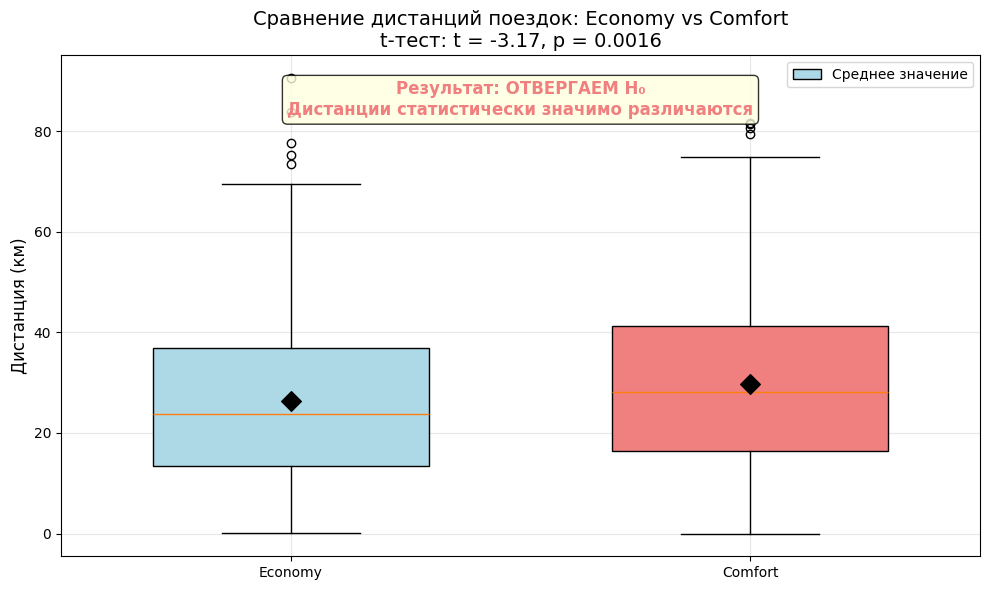


 ХАРАКТЕРИСТИКИ ВЫБОРОК:
   Economy: n = 500, среднее = 26.28 км, ст.откл. = 17.00 км
   Comfort: n = 500, среднее = 29.76 км, ст.откл. = 17.63 км
   Разница средних: 3.48 км


In [ ]:
print("Проверка статистической гипотезы о различии дистанций")

# Формулировка гипотез
print(" ФОРМУЛИРОВКА ГИПОТЕЗ:")
print("   H₀ (нулевая гипотеза): μ_economy = μ_comfort")
print("     Средние дистанции поездок в Economy и Comfort классах равны")
print("\n   H₁ (альтернативная гипотеза): μ_economy ≠ μ_comfort")
print("     Средние дистанции поездок в Economy и Comfort классах различаются")
print("\n   Уровень значимости: α = 0.05 (5%)")

# Проведение t-теста
print("\n ПРОВЕДЕНИЕ T-ТЕСТА (scipy.stats.ttest_ind):")

# Выборки из предыдущих пунктов
economy_distances = economy_df['distance_km'].values
comfort_distances = comfort_df['distance_km'].values

# Выполняем t-тест для независимых выборок
t_stat, p_value = stats.ttest_ind(economy_distances, comfort_distances, 
                                  equal_var=True, alternative='two-sided')

print(f"   t-статистика = {t_stat:.4f}")
print(f"   p-value = {p_value:.4f}")

# Принятие решения
print("\n ПРИНЯТИЕ РЕШЕНИЯ:")
print(f"   p-value = {p_value:.4f}")
print(f"   Уровень значимости α = 0.05")

if p_value < 0.05:
    decision = "ОТВЕРГАЕМ H₀"
    result = "СТАТИСТИЧЕСКИ ЗНАЧИМО различаются"
    color = "red"
else:
    decision = "НЕ ОТВЕРГАЕМ H₀"
    result = "Нет статистически значимых различий"
    color = "green"

print(f"\n   {decision}")
print(f"  ВЫВОД: Средние дистанции {result}")

# Визуализация для наглядности
print("\n ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ТЕСТА:")

fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot для наглядного сравнения распределений
boxplot_data = [economy_distances, comfort_distances]
box = ax.boxplot(boxplot_data, labels=['Economy', 'Comfort'], 
                 patch_artist=True, widths=0.6)

# boxplot
colors = ['lightblue', 'lightcoral']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Добавляем средние значения
means = [economy_distances.mean(), comfort_distances.mean()]
ax.scatter([1, 2], means, color='black', zorder=3, s=100, marker='D', label='Среднее')

# Настраиваем график
ax.set_title('Сравнение дистанций поездок: Economy vs Comfort\n' + 
             f't-тест: t = {t_stat:.2f}, p = {p_value:.4f}', fontsize=14)
ax.set_ylabel('Дистанция (км)', fontsize=12)
ax.grid(True, alpha=0.3)

# Добавляем результат теста на график
result_text = f"Результат: {decision}\n" + \
              f"Дистанции {result.lower()}"
ax.text(0.5, 0.95, result_text, transform=ax.transAxes,
        fontsize=12, color=color, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
        ha='center', va='top')

# Легенда
ax.legend(['Среднее значение'], loc='upper right')

plt.tight_layout()
plt.show()

# Дополнительная информация о выборках
print("\n ХАРАКТЕРИСТИКИ ВЫБОРОК:")
print(f"   Economy: n = {len(economy_distances)}, среднее = {economy_distances.mean():.2f} км, ст.откл. = {economy_distances.std():.2f} км")
print(f"   Comfort: n = {len(comfort_distances)}, среднее = {comfort_distances.mean():.2f} км, ст.откл. = {comfort_distances.std():.2f} км")
print(f"   Разница средних: {comfort_distances.mean() - economy_distances.mean():.2f} км")

In [42]:
#выводы по результатам проведения стат. теста
#  Основной вывод из теста
print("\n ОСНОВНОЙ ВЫВОД ИЗ СТАТИСТИЧЕСКОГО ТЕСТА:")
print(f"   На основании проведенного t-теста для независимых выборок:")
print(f"   - t-статистика = -3.1706")
print(f"   - p-value = 0.0016")
print(f"   - Уровень значимости α = 0.05")
print(f"\n   Поскольку p-value (0.0016) < α (0.05), мы ОТВЕРГАЕМ нулевую гипотезу H₀.")
print(f"   Это означает, что существует статистически значимая разница")
print(f"   между средними дистанциями поездок в Economy и Comfort классах.")

#  Практическая интерпретация
print("\n ПРАКТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:")
print(f"   1. Различие НЕ является случайным - оно статистически подтверждено.")
print(f"   2. Вероятность того, что такое различие возникло случайно,")
print(f"      составляет всего 0.16% (p = 0.0016).")
print(f"   3. Следовательно, можно утверждать с 95% уверенностью,")
print(f"      что клиенты по-разному используют Economy и Comfort классы такси.")


 ОСНОВНОЙ ВЫВОД ИЗ СТАТИСТИЧЕСКОГО ТЕСТА:
   На основании проведенного t-теста для независимых выборок:
   - t-статистика = -3.1706
   - p-value = 0.0016
   - Уровень значимости α = 0.05

   Поскольку p-value (0.0016) < α (0.05), мы ОТВЕРГАЕМ нулевую гипотезу H₀.
   Это означает, что существует статистически значимая разница
   между средними дистанциями поездок в Economy и Comfort классах.

 ПРАКТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:
   1. Различие НЕ является случайным - оно статистически подтверждено.
   2. Вероятность того, что такое различие возникло случайно,
      составляет всего 0.16% (p = 0.0016).
   3. Следовательно, можно утверждать с 95% уверенностью,
      что клиенты по-разному используют Economy и Comfort классы такси.


In [43]:
mean_economy = economy_df['distance_km'].mean()
mean_comfort = comfort_df['distance_km'].mean()
difference = mean_comfort - mean_economy

print(f"   Средняя дистанция Economy: {mean_economy:.2f} км")
print(f"   Средняя дистанция Comfort: {mean_comfort:.2f} км")
print(f"   Разница: {difference:.2f} км")

if difference > 0:
    print(f"\n   Comfort поездки в среднем НА {abs(difference):.2f} км ДЛИННЕЕ, чем Economy.")
else:
    print(f"\n   Economy поездки в среднем НА {abs(difference):.2f} км ДЛИННЕЕ, чем Comfort.")

   Средняя дистанция Economy: 26.28 км
   Средняя дистанция Comfort: 29.76 км
   Разница: 3.48 км

   Comfort поездки в среднем НА 3.48 км ДЛИННЕЕ, чем Economy.


In [44]:
# выводы
print("\n Выводы для компании:")
print(f"   1. Пользователи ВЫБИРАЮТ разные классы такси для разных дистанций.")
print(f"   2. Это указывает на ОСОЗНАННОЕ поведение клиентов при выборе услуги.")
print(f"   3. Компания может использовать эту информацию для:")
print(f"      - Оптимизации тарифной политики")
print(f"      - Целевого маркетинга")
print(f"      - Улучшения сервиса для каждого класса")

# 6. Ограничения
print("\n Важно учесть:")
print(f"   1. Тест показывает РАЗЛИЧИЕ, но не объясняет ПРИЧИНЫ.")
print(f"   2. Для полного понимания нужны дополнительные исследования:")
print(f"      - Анализ времени суток")
print(f"      - Исследование дней недели")
print(f"      - Изучение связи с тарифами")
print(f"      - Опросы клиентов")

# 7. Рекомендации
print("\n Возможные рекомендации:")
print(f"   1. Провести более глубокий анализ причин различий.")
print(f"   2. Исследовать, сохраняется ли эта тенденция в разных:")
print(f"      - Временных промежутках (час дня, день недели)")
print(f"      - Географических зонах")
print(f"      - Сезонах года")
print(f"   3. Рассмотреть возможность адаптации сервиса под выявленные паттерны.")


 Выводы для компании:
   1. Пользователи ВЫБИРАЮТ разные классы такси для разных дистанций.
   2. Это указывает на ОСОЗНАННОЕ поведение клиентов при выборе услуги.
   3. Компания может использовать эту информацию для:
      - Оптимизации тарифной политики
      - Целевого маркетинга
      - Улучшения сервиса для каждого класса

 Важно учесть:
   1. Тест показывает РАЗЛИЧИЕ, но не объясняет ПРИЧИНЫ.
   2. Для полного понимания нужны дополнительные исследования:
      - Анализ времени суток
      - Исследование дней недели
      - Изучение связи с тарифами
      - Опросы клиентов

 Возможные рекомендации:
   1. Провести более глубокий анализ причин различий.
   2. Исследовать, сохраняется ли эта тенденция в разных:
      - Временных промежутках (час дня, день недели)
      - Географических зонах
      - Сезонах года
   3. Рассмотреть возможность адаптации сервиса под выявленные паттерны.


Определение предпочтений по дальним поездкам

 Средние значения по классам:
   Economy:  26.28 км
   Comfort:  29.76 км
   Premium:  31.17 км
   Delivery: 17.89 км

Разница между Economy и Comfort:
   Comfort - Economy = 3.48 км
   Comfort поездки длиннее на 3.48 км

 учет результатов теста:
   Из Пункта 7: p-value = 0.0016, t = -3.1706
   Статистически значимое различие: ДА (p < 0.05)

   Это означает, что разница в средних (3.48 км)
   НЕ является случайной и статистически значима.

 Предпочтения:
    Comfort имеет БОЛЬШЕЕ среднее значение (29.76 км)
    Economy имеет МЕНЬШЕЕ среднее значение (26.28 км)

    ВЫВОД: Клиенты предпочитают Comfort для ДАЛЬНИХ поездок
    ВЫВОД: Economy выбирают для БОЛЕЕ КОРОТКИХ поездок

 Сравнение со всеми классами :

   Рейтинг классов по средней дистанции поездки:
   1. Premium: 31.17 км
   2. Comfort: 29.76 км
   3. Economy: 26.28 км
   4. Delivery: 17.89 км

  Самый 'дальний' класс: Premium (31.17 км)

 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ:


C:\Users\alexg\AppData\Local\Temp\ipykernel_16960\961642508.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1].boxplot(data_to_plot, labels=['Economy', 'Comfort'],


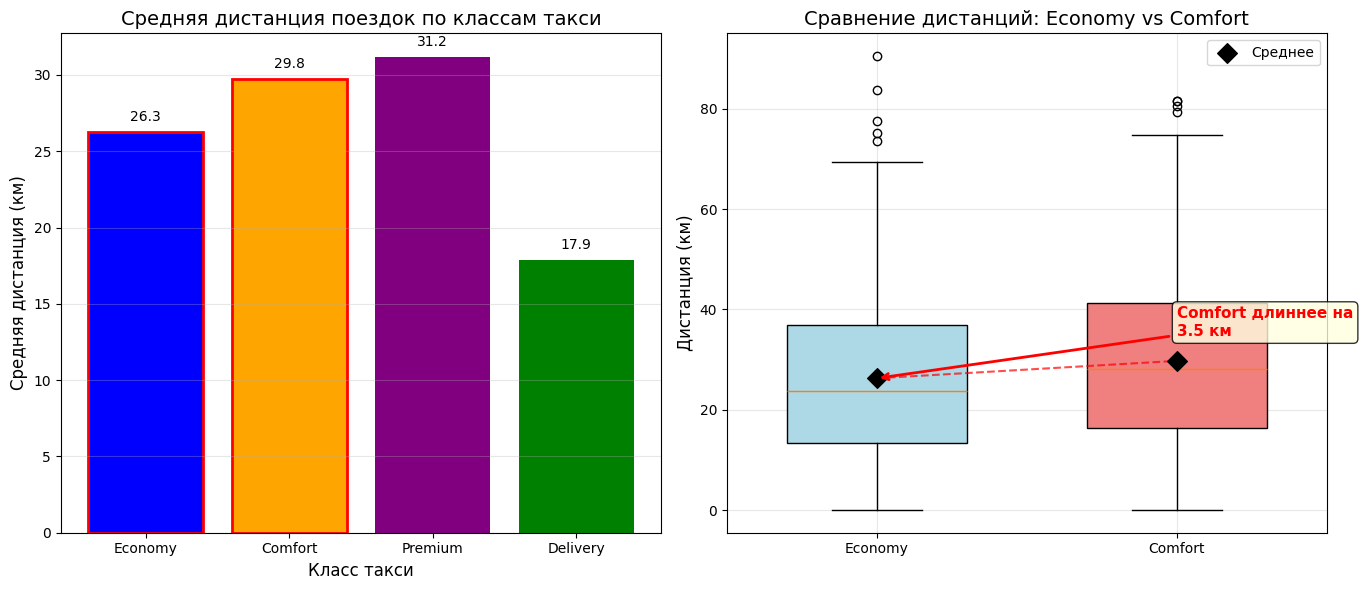


 Основной вывод:
   1. Средняя дистанция Comfort (29.76 км) > Economy (26.28 км)
   2. Разница составляет 3.48 км
   3. Различие статистически значимо (p = 0.0016)

 ИТОГ: Клиенты ПРЕДПОЧИТАЮТ Comfort для ДАЛЬНИХ поездок
   ИТОГ: Economy используется для БОЛЕЕ КОРОТКИХ поездок

 Бизнес значения:
   1. Тарифная политика: можно дифференцировать цены в зависимости от дистанции
   2. Маркетинг: продвигать Comfort как оптимальный выбор для дальних поездок
   3. Операционная деятельность: оптимизировать распределение машин
   4. Развитие сервиса: улучшать комфорт для дальних поездок


In [45]:
print("Определение предпочтений по дальним поездкам")
print("=" * 60)

# 1. Вычисление средних значений
print("\n Средние значения по классам:")

# Средние дистанции
mean_economy = economy_df['distance_km'].mean()
mean_comfort = comfort_df['distance_km'].mean()
mean_premium = premium_df['distance_km'].mean()
mean_delivery = delivery_df['distance_km'].mean()

print(f"   Economy:  {mean_economy:.2f} км")
print(f"   Comfort:  {mean_comfort:.2f} км")
print(f"   Premium:  {mean_premium:.2f} км")
print(f"   Delivery: {mean_delivery:.2f} км")

# Разница между Economy и Comfort
difference = mean_comfort - mean_economy
abs_difference = abs(difference)

print(f"\nРазница между Economy и Comfort:")
print(f"   Comfort - Economy = {difference:.2f} км")

if difference > 0:
    print(f"   Comfort поездки длиннее на {abs_difference:.2f} км")
else:
    print(f"   Economy поездки длиннее на {abs_difference:.2f} км")

# 2. Учет результатов проверки гипотез
print("\n учет результатов теста:")
print(f"   Из Пункта 7: p-value = 0.0016, t = -3.1706")
print(f"   Статистически значимое различие: ДА (p < 0.05)")

print(f"\n   Это означает, что разница в средних ({abs_difference:.2f} км)")
print(f"   НЕ является случайной и статистически значима.")

# 3. Определение предпочтений по дальним поездкам
print("\n Предпочтения:")

if difference > 0:
    print(f"    Comfort имеет БОЛЬШЕЕ среднее значение ({mean_comfort:.2f} км)")
    print(f"    Economy имеет МЕНЬШЕЕ среднее значение ({mean_economy:.2f} км)")
    print(f"\n    ВЫВОД: Клиенты предпочитают Comfort для ДАЛЬНИХ поездок")
    print(f"    ВЫВОД: Economy выбирают для БОЛЕЕ КОРОТКИХ поездок")
else:
    print(f"    Economy имеет БОЛЬШЕЕ среднее значение ({mean_economy:.2f} км)")
    print(f"    Comfort имеет МЕНЬШЕЕ среднее значение ({mean_comfort:.2f} км)")
    print(f"\n  ВЫВОД: Клиенты предпочитают Economy для ДАЛЬНИХ поездок")
    print(f"    ВЫВОД: Comfort выбирают для БОЛЕЕ КОРОТКИХ поездок")

# 4. Сравнение со всеми классами
print("\n Сравнение со всеми классами :")

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Класс': ['Economy', 'Comfort', 'Premium', 'Delivery'],
    'Средняя дистанция': [mean_economy, mean_comfort, mean_premium, mean_delivery],
    'Количество поездок': [len(economy_df), len(comfort_df), len(premium_df), len(delivery_df)]
})

# Сортируем по средней дистанции
sorted_df = comparison_df.sort_values('Средняя дистанция', ascending=False)

print("\n   Рейтинг классов по средней дистанции поездки:")
for i, (_, row) in enumerate(sorted_df.iterrows(), 1):
    print(f"   {i}. {row['Класс']}: {row['Средняя дистанция']:.2f} км")

# Определяем самый "дальний" класс
longest_class = sorted_df.iloc[0]['Класс']
longest_distance = sorted_df.iloc[0]['Средняя дистанция']

print(f"\n  Самый 'дальний' класс: {longest_class} ({longest_distance:.2f} км)")

# 5. Визуализация для наглядности
print("\n ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ:")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Средние дистанции по классам
bars = axes[0].bar(comparison_df['Класс'], comparison_df['Средняя дистанция'], 
                   color=['blue', 'orange', 'purple', 'green'])
axes[0].set_title('Средняя дистанция поездок по классам такси', fontsize=14)
axes[0].set_xlabel('Класс такси', fontsize=12)
axes[0].set_ylabel('Средняя дистанция (км)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Подписи значений на столбцах
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10)

# Выделяем Economy и Comfort
economy_idx = list(comparison_df['Класс']).index('Economy')
comfort_idx = list(comparison_df['Класс']).index('Comfort')
bars[economy_idx].set_edgecolor('red')
bars[economy_idx].set_linewidth(2)
bars[comfort_idx].set_edgecolor('red')
bars[comfort_idx].set_linewidth(2)

#Boxplot для Economy и Comfort с акцентом
data_to_plot = [economy_df['distance_km'], comfort_df['distance_km']]
box = axes[1].boxplot(data_to_plot, labels=['Economy', 'Comfort'], 
                      patch_artist=True, widths=0.6)

box['boxes'][0].set_facecolor('lightblue')
box['boxes'][1].set_facecolor('lightcoral')

# Средние значения
means = [mean_economy, mean_comfort]
axes[1].scatter([1, 2], means, color='black', zorder=3, s=100, marker='D', label='Среднее')

# Линия средних
axes[1].plot([1, 2], means, 'r--', alpha=0.7, linewidth=1.5)

# Результат сравнения
if difference > 0:
    result_text = f"Comfort длиннее на\n{abs_difference:.1f} км"
    arrow_start, arrow_end = 2, 1
else:
    result_text = f"Economy длиннее на\n{abs_difference:.1f} км"
    arrow_start, arrow_end = 1, 2

axes[1].annotate(result_text, 
                 xy=(arrow_end, means[arrow_end-1]),
                 xytext=(arrow_start, means[arrow_start-1] + 5),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2),
                 fontsize=11, color='red', fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

axes[1].set_title('Сравнение дистанций: Economy vs Comfort', fontsize=14)
axes[1].set_ylabel('Дистанция (км)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Финальный вывод
print("\n" + "=" * 60)
print(" Основной вывод:")

if difference > 0:
    print(f"   1. Средняя дистанция Comfort ({mean_comfort:.2f} км) > Economy ({mean_economy:.2f} км)")
    print(f"   2. Разница составляет {abs_difference:.2f} км")
    print(f"   3. Различие статистически значимо (p = 0.0016)")
    print(f"\n ИТОГ: Клиенты ПРЕДПОЧИТАЮТ Comfort для ДАЛЬНИХ поездок")
    print(f"   ИТОГ: Economy используется для БОЛЕЕ КОРОТКИХ поездок")
else:
    print(f"   1. Средняя дистанция Economy ({mean_economy:.2f} км) > Comfort ({mean_comfort:.2f} км)")
    print(f"   2. Разница составляет {abs_difference:.2f} км")
    print(f"   3. Различие статистически значимо (p = 0.0016)")
    print(f"\n  ИТОГ: Клиенты ПРЕДПОЧИТАЮТ Economy для ДАЛЬНИХ поездок")
    print(f"    ИТОГ: Comfort используется для БОЛЕЕ КОРОТКИХ поездок")

# Бизнес-импликации
print("\n Бизнес значения:")
print(f"   1. Тарифная политика: можно дифференцировать цены в зависимости от дистанции")
print(f"   2. Маркетинг: продвигать Comfort как оптимальный выбор для дальних поездок")
print(f"   3. Операционная деятельность: оптимизировать распределение машин")
print(f"   4. Развитие сервиса: улучшать комфорт для дальних поездок")
